<a href="https://colab.research.google.com/github/AlhousseineDiallo/100-pandas-puzzles/blob/master/Projet_Transport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv(filepath_or_buffer='/content/drive/MyDrive/datasets/dataset_planification_transport_LK.csv')

In [ ]:
df_copy = df.copy()

In [ ]:
df.head(n=5)

,trajet_id,ville_depart,ville_arrivee,distance_km,duree_prevue_h,retard_min,prix_billet,nb_passagers,capacite_bus,type_bus,jour_semaine,periode_depart,condition_route,carburant_litre,satisfaction_client
0,1,Tsévié,Tsévié,56.0,7.2,163.0,8847.0,52.0,50.0,Climatisé,Dimanche,Après-midi,Bonne,43.4,3
1,2,Sokodé,Tsévié,NaN,2.9,124.0,9401.0,39.0,NaN,Standard,Dimanche,NaN,Moyenne,73.7,4
2,3,Dapaong,Sokodé,496.0,1.6,163.0,9228.0,56.0,NaN,Standard,Dimanche,Soir,Bonne,26.5,2
3,4,Sokodé,Lomé,463.0,8.8,88.0,3618.0,NaN,NaN,VIP,Jeudi,Matin,Mauvaise,42.5,4
4,5,Kara,Dapaong,130.0,3.4,32.0,7518.0,67.0,50.0,VIP,Dimanche,Après-midi,Mauvaise,21.5,1


In [ ]:
# on va commencer par l'EDA
column_names = df.columns.tolist()

In [ ]:
column_names

['trajet_id',
 'ville_depart',
 'ville_arrivee',
 'distance_km',
 'duree_prevue_h',
 'retard_min',
 'prix_billet',
 'nb_passagers',
 'capacite_bus',
 'type_bus',
 'jour_semaine',
 'periode_depart',
 'condition_route',
 'carburant_litre',
 'satisfaction_client']

In [ ]:
df.shape
print(f"le dataframe a {df.shape[0]} lignes/enregistrements et {df.shape[1]} colonnes".center(100, '-'))

---------------------le dataframe a 2000 lignes/enregistrements et 15 colonnes----------------------


In [ ]:
buffer = io.StringIO()
df.info(buf=buffer, memory_usage='deep')
df_info = buffer.getvalue()
print(df_info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   trajet_id            2000 non-null   int64  
 1   ville_depart         1844 non-null   object 
 2   ville_arrivee        1840 non-null   object 
 3   distance_km          1840 non-null   float64
 4   duree_prevue_h       1840 non-null   float64
 5   retard_min           1840 non-null   float64
 6   prix_billet          1840 non-null   float64
 7   nb_passagers         1836 non-null   float64
 8   capacite_bus         1840 non-null   float64
 9   type_bus             1840 non-null   object 
 10  jour_semaine         1840 non-null   object 
 11  periode_depart       1840 non-null   object 
 12  condition_route      1840 non-null   object 
 13  carburant_litre      1840 non-null   float64
 14  satisfaction_client  2000 non-null   int64  
dtypes: float64(7), int64(2), object(6)
mem

In [ ]:
# les doublons
df.duplicated(keep='first', subset=None).sum()

np.int64(0)

In [ ]:
# on va verifier l'unicite de notre id
df['trajet_id'].is_unique
# c'est donc le cas comme le montre l'output

True

In [ ]:
# on va verifier les doublons par rapport a des colonnes dont la combinaison doit logiquement etre unique
df.duplicated(subset=['trajet_id', 'ville_depart', 'jour_semaine']).sum()

np.int64(0)

In [ ]:
# les donnees sont vides de doublons

In [ ]:
# maintenant les valeurs manquantes
df.isna().sum(axis=0)

,0
trajet_id,0
ville_depart,156
ville_arrivee,160
distance_km,160
duree_prevue_h,160
retard_min,160
prix_billet,160
nb_passagers,164
capacite_bus,160
type_bus,160


In [ ]:
# on va voir les proportions de nos donnees manquantes
for col in column_names:
  null_percent = np.mean(df[col].isna()) * 100
  print(f"{col} -> {null_percent:.2f} %")

trajet_id -> 0.00 %
ville_depart -> 7.80 %
ville_arrivee -> 8.00 %
distance_km -> 8.00 %
duree_prevue_h -> 8.00 %
retard_min -> 8.00 %
prix_billet -> 8.00 %
nb_passagers -> 8.20 %
capacite_bus -> 8.00 %
type_bus -> 8.00 %
jour_semaine -> 8.00 %
periode_depart -> 8.00 %
condition_route -> 8.00 %
carburant_litre -> 8.00 %
satisfaction_client -> 0.00 %


In [ ]:
df.shape[1]

15

In [ ]:
# on va verifier les lignes qui n'ont que des valeurs manquantes
df.isna().sum(axis=1)[df.isna().sum(axis=1) >= 4]

,0
66,5
81,6
95,4
102,4
208,4
216,4
316,5
366,4
385,4
412,4


In [ ]:
df.head()

,trajet_id,ville_depart,ville_arrivee,distance_km,duree_prevue_h,retard_min,prix_billet,nb_passagers,capacite_bus,type_bus,jour_semaine,periode_depart,condition_route,carburant_litre,satisfaction_client
0,1,Tsévié,Tsévié,56.0,7.2,163.0,8847.0,52.0,50.0,Climatisé,Dimanche,Après-midi,Bonne,43.4,3
1,2,Sokodé,Tsévié,NaN,2.9,124.0,9401.0,39.0,NaN,Standard,Dimanche,NaN,Moyenne,73.7,4
2,3,Dapaong,Sokodé,496.0,1.6,163.0,9228.0,56.0,NaN,Standard,Dimanche,Soir,Bonne,26.5,2
3,4,Sokodé,Lomé,463.0,8.8,88.0,3618.0,NaN,NaN,VIP,Jeudi,Matin,Mauvaise,42.5,4
4,5,Kara,Dapaong,130.0,3.4,32.0,7518.0,67.0,50.0,VIP,Dimanche,Après-midi,Mauvaise,21.5,1


In [ ]:
# on va voir les donnees de nos colonnes
df.dtypes

,0
trajet_id,int64
ville_depart,object
ville_arrivee,object
distance_km,float64
duree_prevue_h,float64
retard_min,float64
prix_billet,float64
nb_passagers,float64
capacite_bus,float64
type_bus,object


In [ ]:
# les donnees uniques par colonnes
df.nunique()

,0
trajet_id,2000
ville_depart,6
ville_arrivee,6
distance_km,574
duree_prevue_h,106
retard_min,180
prix_billet,1697
nb_passagers,66
capacite_bus,5
type_bus,3


In [ ]:
df['capacite_bus'].unique()

array([50., nan, 30., 40., 70., 60.])

In [ ]:
df['type_bus'].unique()

array(['Climatisé', 'Standard', 'VIP', nan], dtype=object)

In [ ]:
df['jour_semaine'].unique()

array(['Dimanche', 'Jeudi', 'Samedi', 'Mardi', nan, 'Mercredi',
       'Vendredi', 'Lundi'], dtype=object)

In [ ]:
df['condition_route'].unique()

array(['Bonne', 'Moyenne', 'Mauvaise', nan], dtype=object)

In [ ]:
df['nb_passagers'].unique()

array([52., 39., 56., nan, 67., 26., 43., 20., 66., 29., 31., 25.,  7.,
       21., 59., 55., 69., 60., 18., 57., 46., 34., 63., 22., 45., 37.,
        8., 30., 15., 12., 48.,  6., 17., 64., 42., 68., 10., 41., 36.,
       13., 16., 49., 79., 51., 23.,  9., 35., 38., 50., 19., 11.,  5.,
       28., 44., 40., 62., 27., 24., 14., 32., 61., 33., 65., 54., 53.,
       58., 47.])

In [ ]:
# on va convertir les colonnes categorielles en objet category pandas
categorical_columns = [
    'ville_depart',
    'ville_arrivee',
    'type_bus',
    'jour_semaine',
    'periode_depart',
    'condition_route'
]
for col in categorical_columns:
  df[col] = df[col].astype(dtype='category', errors='ignore')


In [ ]:
df.dtypes

,0
trajet_id,int64
ville_depart,category
ville_arrivee,category
distance_km,float64
duree_prevue_h,float64
retard_min,float64
prix_billet,float64
nb_passagers,float64
capacite_bus,float64
type_bus,category


In [ ]:
# on va observer la distribution de certaines colonnes continues
# distance_km

In [ ]:
# configuration initiale
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.style'] = 'italic'

# les configurations des titres
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titleweight'] = 'bold'

In [ ]:
sns.set_style(style='darkgrid')

In [ ]:
# quelles sont mes colonnes numeriques
df.select_dtypes(include=np.number).columns

Index(['trajet_id', 'distance_km', 'duree_prevue_h', 'retard_min',
       'prix_billet', 'nb_passagers', 'capacite_bus', 'carburant_litre',
       'satisfaction_client'],
      dtype='object')

In [ ]:
df.filter(items=df.select_dtypes(include=np.number).columns).sample(frac=.01)

,trajet_id,distance_km,duree_prevue_h,retard_min,prix_billet,nb_passagers,capacite_bus,carburant_litre,satisfaction_client
169,170,344.0,3.7,NaN,3307.0,48.0,40.0,NaN,3
759,760,253.0,3.1,70.0,NaN,NaN,30.0,NaN,4
1056,1057,102.0,8.7,80.0,3214.0,53.0,70.0,59.8,5
1388,1389,441.0,8.3,159.0,9491.0,16.0,50.0,29.3,2
1074,1075,615.0,1.7,94.0,3109.0,17.0,70.0,68.9,1
1842,1843,194.0,9.7,114.0,5321.0,26.0,40.0,64.6,3
322,323,467.0,11.8,173.0,6826.0,55.0,60.0,18.7,1
1971,1972,220.0,3.1,58.0,11595.0,55.0,30.0,59.3,5
1060,1061,78.0,10.8,26.0,9916.0,50.0,30.0,37.2,2
1042,1043,478.0,4.4,NaN,11055.0,5.0,30.0,19.0,2


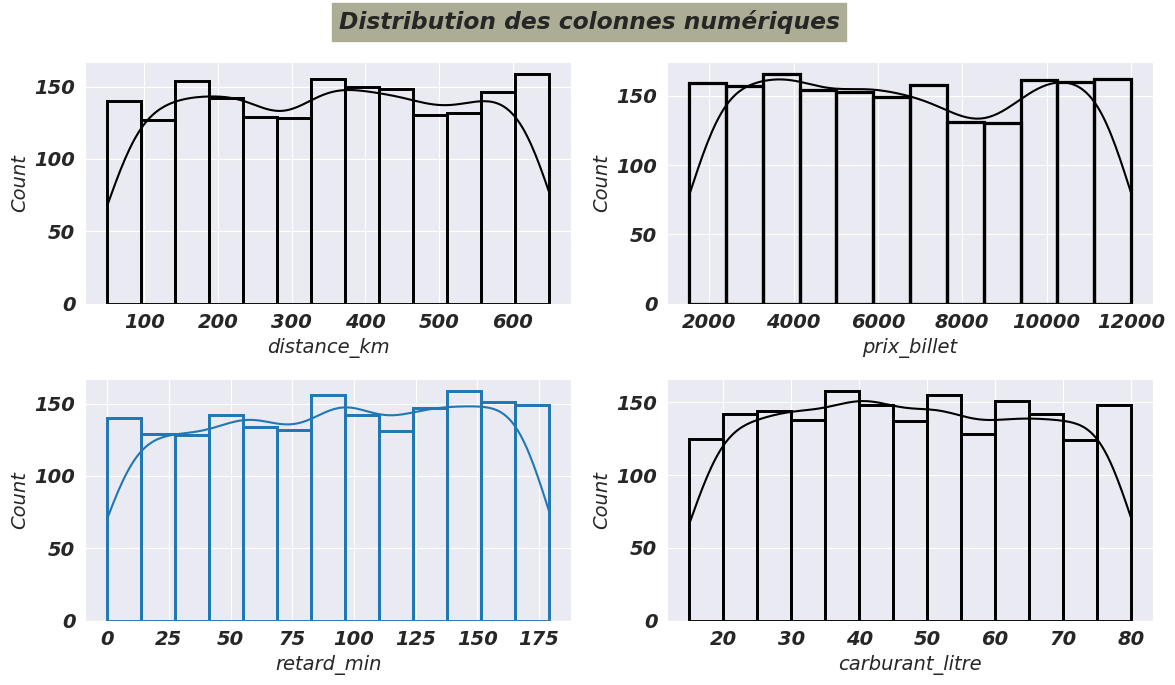

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, sharey=False, sharex=False)
# on va configurer un title commun
fig.suptitle(t='Distribution des colonnes numériques', backgroundcolor='#ACAD94', fontweight='bold')

# distance_km
sns.histplot(data=df,
             x='distance_km',
             kde=True,
             lw=2.2,
             color='k',
             fill=False,
             ax=axes[0, 0]
             )
# prix_billet
sns.histplot(data=df,
             x='prix_billet',
             kde=True,
             fill=False,
             color='k',
             lw=2.2,
             ax=axes[0, 1])

# retard minutes
sns.histplot(data=df,
             x='retard_min',
             kde=True,
             fill=False,
             lw=2.2,
             ax=axes[1, 0])

# carburant_litre
sns.histplot(data=df,
             x='carburant_litre',
             fill=False,
             kde=True,
             lw=2.2,
             color='k',
             ax=axes[1, 1])
plt.tight_layout()
plt.show();

## on voit donc une distribution uniforme de nos donnees ce qui est plutot bien !

In [ ]:
# on va maintenant voir describe
df.describe(include='number').round(decimals=2).iloc[:, 1:-1]

,distance_km,duree_prevue_h,retard_min,prix_billet,nb_passagers,capacite_bus,carburant_litre
count,1840.00,1840.00,1840.00,1840.00,1836.00,1840.00,1840.00
mean,352.98,6.78,91.69,6726.46,37.99,50.32,47.51
std,173.61,2.98,51.89,3071.40,19.12,13.97,18.56
min,50.00,1.50,0.00,1528.00,5.00,30.00,15.00
25%,203.00,4.20,48.00,4008.00,21.00,40.00,31.58
50%,355.00,6.90,93.00,6599.00,39.00,50.00,47.35
75%,503.00,9.30,137.00,9527.00,54.00,60.00,63.50
max,649.00,12.00,179.00,11997.00,79.00,70.00,80.00


In [ ]:
df['ville_arrivee'].eq(other=df['ville_depart']).sum()
# verification de la coherence des données: c'est a dire les ligne où la ville de depart = ville d'arrivee

np.int64(326)

In [ ]:
# on va filtrer ces ligne pour continue l'analyse
df = df.query(expr="ville_depart != ville_arrivee", inplace=False, engine='python')

In [ ]:
# controle
df['ville_arrivee'].eq(other=df['ville_depart']).sum()

np.int64(0)

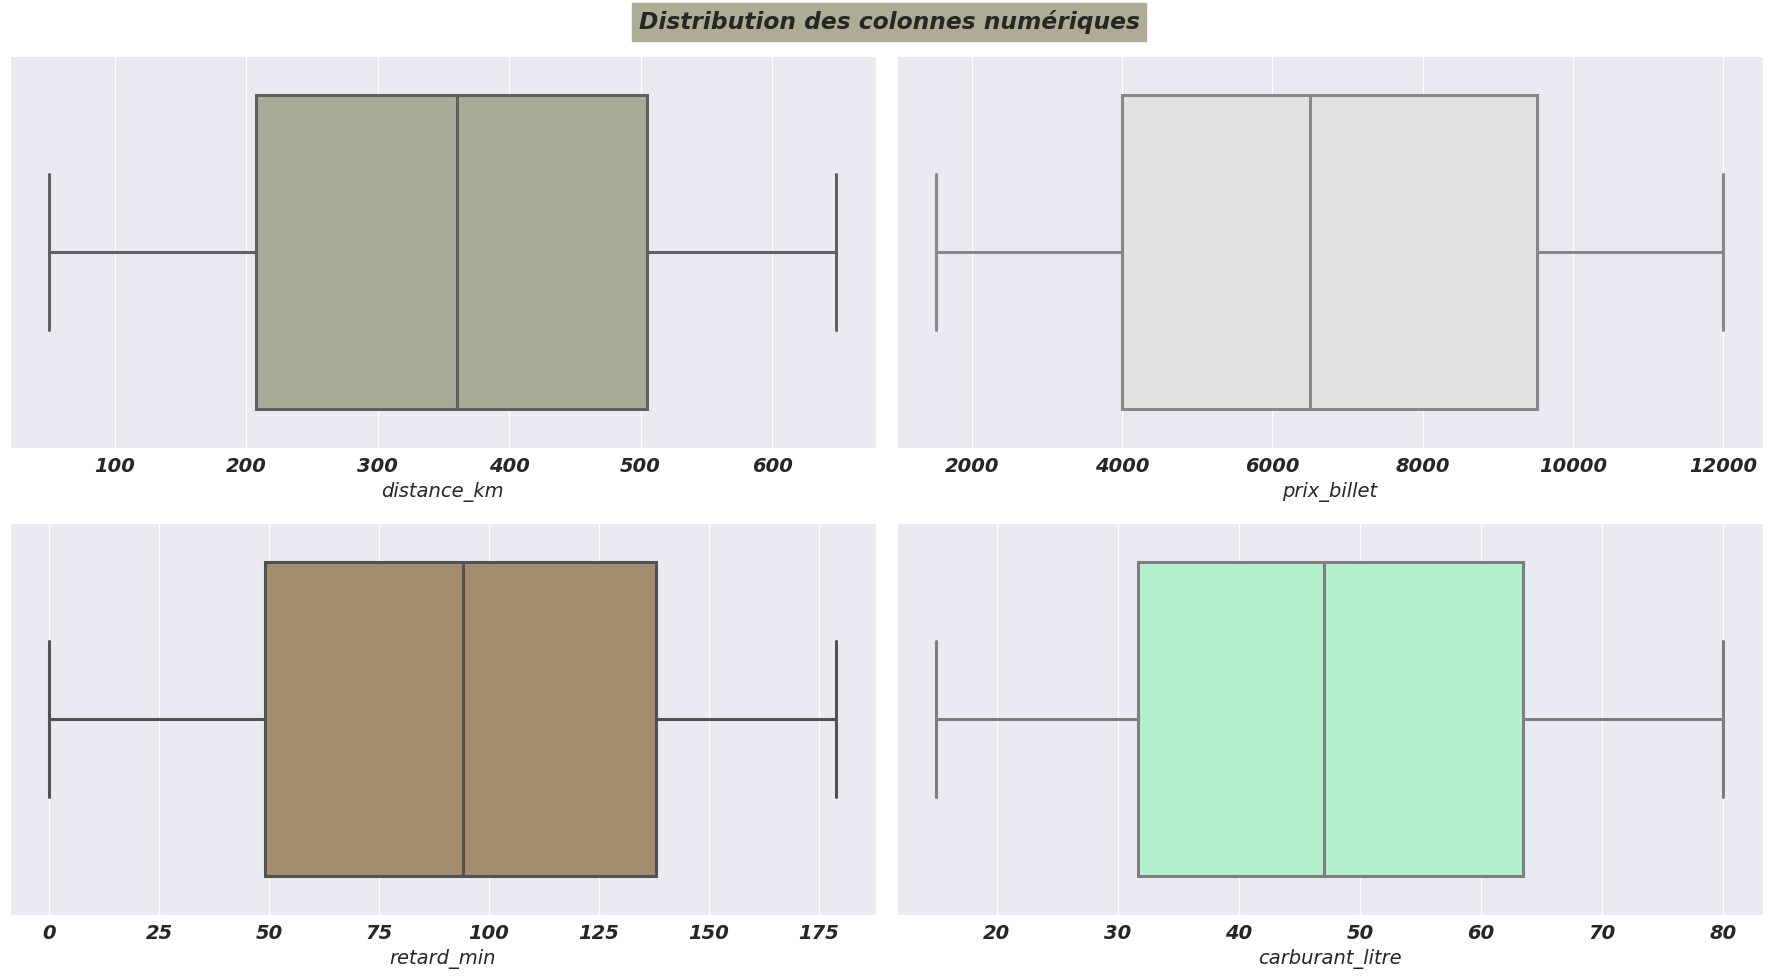

In [ ]:
# on va voir la distribution par rapport aux quantiles avec un boxplot

fig, axes = plt.subplots(nrows=2, ncols=2, sharey=False, sharex=False, figsize=(18, 10))
# on va configurer un title commun
fig.suptitle(t='Distribution des colonnes numériques', backgroundcolor='#ACAD94', fontweight='bold')

# distance_km
sns.boxplot(data=df,
             x='distance_km',
             linewidth=2.2,
             color='#ACAD94',
             ax=axes[0, 0]
             )
# prix_billet
sns.boxplot(data=df,
             x='prix_billet',
             color='#E2E2E2',
             linewidth=2.2,
             ax=axes[0, 1])

# retard minutes
sns.boxplot(data=df,
             x='retard_min',
             linewidth=2.2,
             color='#AA8F66',
             ax=axes[1, 0])

# carburant_litre
sns.boxplot(data=df,
             x='carburant_litre',
             linewidth=2.2,
             color='#AAFAC8',
             ax=axes[1, 1])
plt.tight_layout()
plt.show();

## tout cela corrobore bien les indicateurs statisques et la distribution uniforme de données mises en évidence par notre histogramme

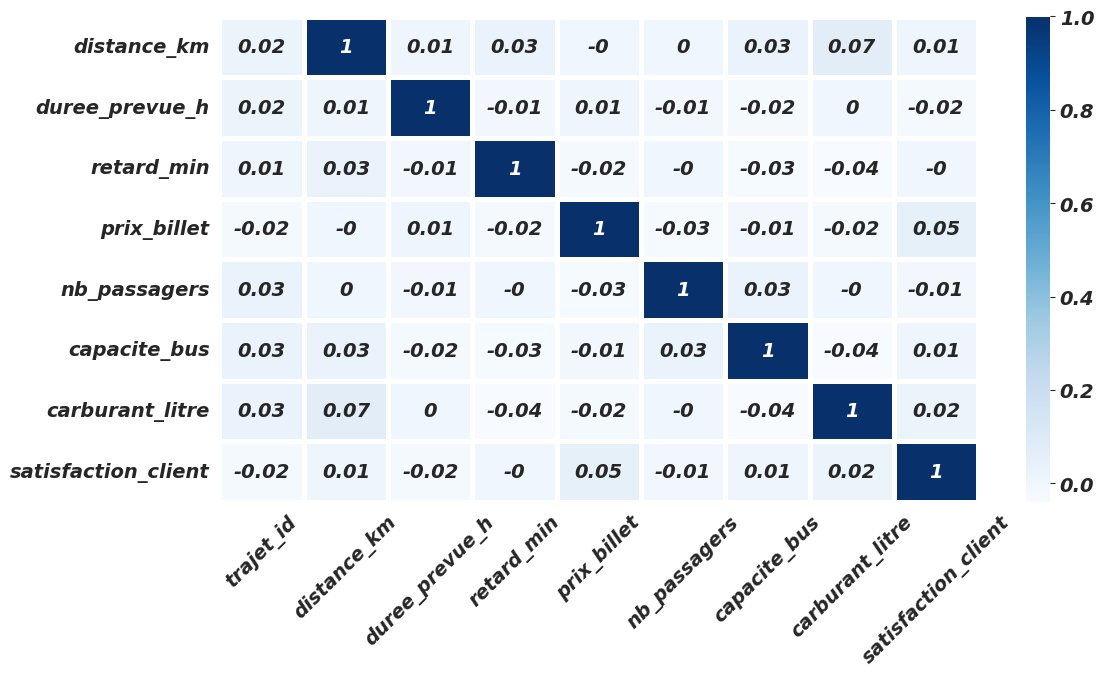

In [ ]:
# etudions les correlations lineaires entre nos donnees
corr_matrix = df.corr(numeric_only=True).round(decimals=2
                                 ).iloc[1:]

# creation d'une matrice de correlations
sns.heatmap(data=corr_matrix, cmap='Blues', lw=2.2, annot=True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();

In [ ]:
column_names

['trajet_id',
 'ville_depart',
 'ville_arrivee',
 'distance_km',
 'duree_prevue_h',
 'retard_min',
 'prix_billet',
 'nb_passagers',
 'capacite_bus',
 'type_bus',
 'jour_semaine',
 'periode_depart',
 'condition_route',
 'carburant_litre',
 'satisfaction_client']

In [ ]:
df['periode_depart'].isna().sum()

np.int64(131)

In [ ]:
df['nb_passagers'].gt(other=df['capacite_bus']).sum()

np.int64(456)

In [ ]:
# on va maintenant voir la surcharge globale avant de continuer
df['surcharge'] = df.apply(func=lambda x: x['nb_passagers'] - x['capacite_bus'] if (x['nb_passagers'] > x['capacite_bus']) else 0, axis=1)

In [ ]:
df['surcharge'].head()

,surcharge
1,0.0
2,0.0
3,0.0
4,17.0
5,0.0


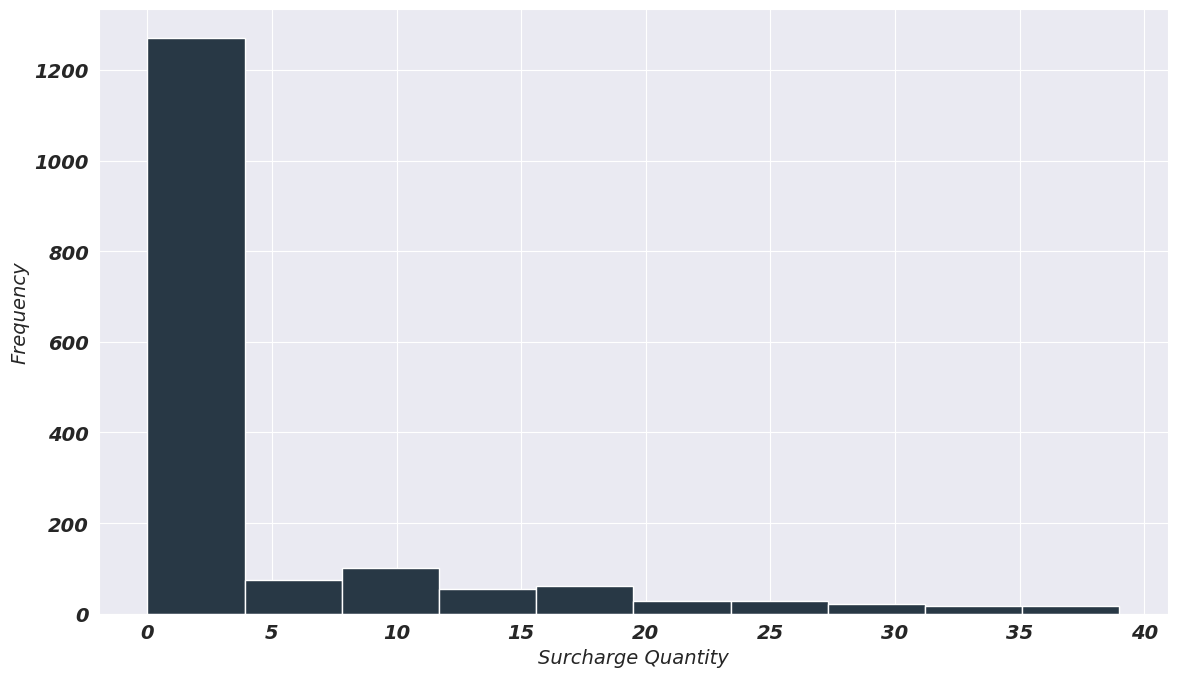

In [ ]:
# on va voir la distribution de notre surcharge
df['surcharge'].plot(kind='hist',
                     color='#283845',
                     lw=2.2,
                     ec='k'
                     )
plt.xlabel(xlabel='Surcharge Quantity')
plt.tight_layout()
plt.show()

In [ ]:
df['periode_depart'].unique()

[NaN, 'Soir', 'Matin', 'Après-midi']
Categories (3, object): ['Après-midi', 'Matin', 'Soir']

In [ ]:
# on va definir nos features
features = ['retard_min',
            'prix_billet',
            'condition_route',
            'type_bus']

In [ ]:
column_names

['trajet_id',
 'ville_depart',
 'ville_arrivee',
 'distance_km',
 'duree_prevue_h',
 'retard_min',
 'prix_billet',
 'nb_passagers',
 'capacite_bus',
 'type_bus',
 'jour_semaine',
 'periode_depart',
 'condition_route',
 'carburant_litre',
 'satisfaction_client']

In [ ]:
# aussi on va creer une variable de surcharge binaire
df['est_surcharged'] = (df['surcharge'] > 0).astype(dtype=pd.Int32Dtype())

In [ ]:
# on va continuer sur du feature engineering
# on va creer une variable pour le prix par km
df['prix_km'] = df['prix_billet'] / df['distance_km']

In [ ]:
# duree_prevue_min
# on va convertir cette feature en min
df['duree_prevue_min'] = df['duree_prevue_h'] * 60

In [ ]:
df.head(n=5)

,trajet_id,ville_depart,ville_arrivee,distance_km,duree_prevue_h,retard_min,prix_billet,nb_passagers,capacite_bus,type_bus,jour_semaine,periode_depart,condition_route,carburant_litre,satisfaction_client,surcharge,est_surcharged,prix_km
1,2,Sokodé,Tsévié,NaN,2.9,124.0,9401.0,39.0,NaN,Standard,Dimanche,NaN,Moyenne,73.7,4,0.0,0,NaN
2,3,Dapaong,Sokodé,496.0,1.6,163.0,9228.0,56.0,NaN,Standard,Dimanche,Soir,Bonne,26.5,2,0.0,0,18.604839
3,4,Sokodé,Lomé,463.0,8.8,88.0,3618.0,NaN,NaN,VIP,Jeudi,Matin,Mauvaise,42.5,4,0.0,0,7.814255
4,5,Kara,Dapaong,130.0,3.4,32.0,7518.0,67.0,50.0,VIP,Dimanche,Après-midi,Mauvaise,21.5,1,17.0,1,57.830769
5,6,Atakpamé,Dapaong,643.0,7.7,172.0,3194.0,26.0,30.0,Standard,Samedi,Soir,Bonne,46.1,1,0.0,0,4.967341


In [ ]:
df.shape

(1674, 18)

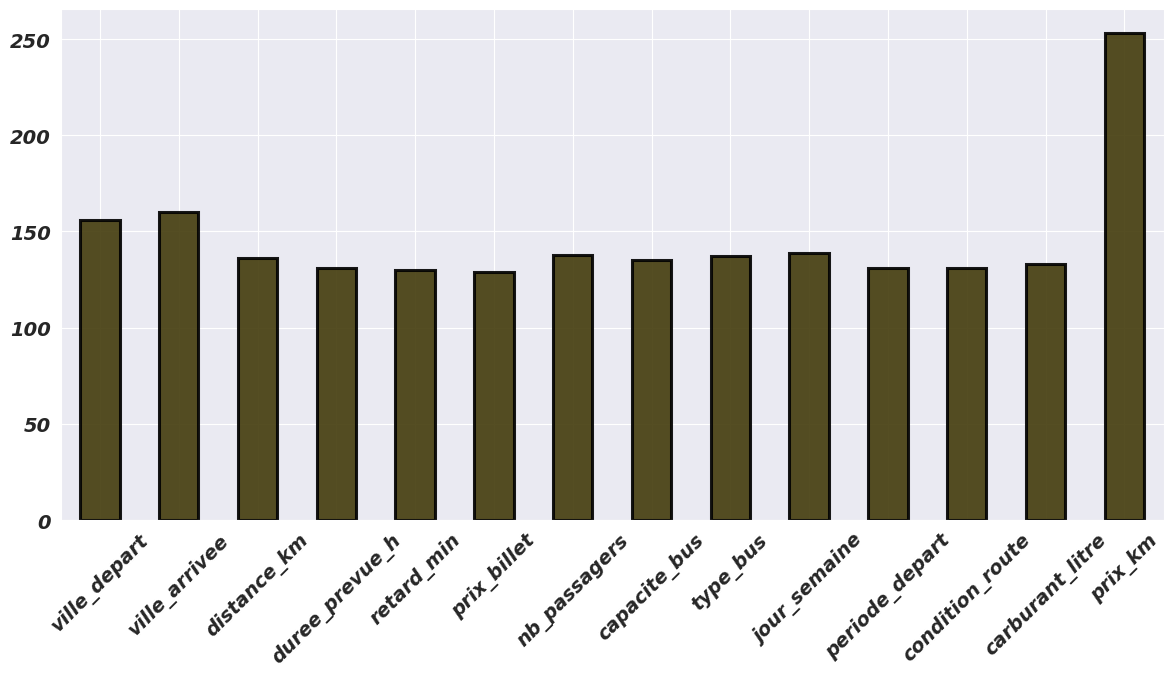

In [ ]:
# let's check again the number of nan in the data
df.isna().sum(axis=0)[df.isna().sum(axis=0) > 0].plot(kind='bar', ec='k', lw=2.2, alpha=.9, color='#423B0B')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

In [ ]:
# verification de la pertinence de nos donnees
for col in numeric_columns:
  if df[col].lt(other=0).any():
    bad_data = df[col].lt(other=0).sum()
    print(f"{col} -> {bad_data}\n".center(50, '-'))

In [ ]:
# preparation pour l'entrainement du modele
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

In [ ]:
column_names

['trajet_id',
 'ville_depart',
 'ville_arrivee',
 'distance_km',
 'duree_prevue_h',
 'retard_min',
 'prix_billet',
 'nb_passagers',
 'capacite_bus',
 'type_bus',
 'jour_semaine',
 'periode_depart',
 'condition_route',
 'carburant_litre',
 'satisfaction_client']

In [ ]:
df.dtypes

,0
trajet_id,int64
ville_depart,category
ville_arrivee,category
distance_km,float64
duree_prevue_h,float64
retard_min,float64
prix_billet,float64
nb_passagers,float64
capacite_bus,float64
type_bus,category


In [ ]:
# on va definir des listes contenant nos colonnes en fonction du type de variable auxquelles elles appartiennent
ordinal_vars = {
    'type_bus': ['Standard', 'Climatisé', 'VIP'],
    'periode_depart': ['Matin', 'Après-midi', 'Soir'],
    'condition_route': ['Mauvaise', 'Moyenne', 'Bonne']
}

In [ ]:
df.corr(method='spearman', numeric_only=True)

,trajet_id,distance_km,duree_prevue_h,retard_min,prix_billet,nb_passagers,capacite_bus,carburant_litre,satisfaction_client,surcharge,est_surcharged,prix_km
trajet_id,1.000000,0.017796,0.016835,0.009640,-0.022427,0.030975,0.031918,0.030891,-0.015045,0.020425,0.018254,-0.025821
distance_km,0.017796,1.000000,0.008760,0.033147,-0.004213,0.003094,0.029743,0.065365,0.009024,-0.005633,-0.011095,-0.718673
duree_prevue_h,0.016835,0.008760,1.000000,-0.002937,0.007206,-0.005518,-0.021049,0.001656,-0.021203,0.001243,-0.006556,-0.003359
retard_min,0.009640,0.033147,-0.002937,1.000000,-0.025266,-0.005562,-0.029360,-0.035693,-0.001847,0.006553,0.010279,-0.037312
prix_billet,-0.022427,-0.004213,0.007206,-0.025266,1.000000,-0.024220,-0.003208,-0.016957,0.050634,-0.016613,-0.025485,0.648845
nb_passagers,0.030975,0.003094,-0.005518,-0.005562,-0.024220,1.000000,0.024289,-0.002254,-0.012155,0.616311,0.603571,-0.027863
capacite_bus,0.031918,0.029743,-0.021049,-0.029360,-0.003208,0.024289,1.000000,-0.037831,0.011734,-0.441714,-0.410259,-0.033202
carburant_litre,0.030891,0.065365,0.001656,-0.035693,-0.016957,-0.002254,-0.037831,1.000000,0.024501,-0.005161,-0.010910,-0.054181
satisfaction_client,-0.015045,0.009024,-0.021203,-0.001847,0.050634,-0.012155,0.011734,0.024501,1.000000,-0.028550,-0.018583,0.009962
surcharge,0.020425,-0.005633,0.001243,0.006553,-0.016613,0.616311,-0.441714,-0.005161,-0.028550,1.000000,0.983479,0.003021


In [ ]:
for col in ordinal_vars.keys():
  print(df[col].unique().tolist())

['Standard', 'VIP', 'Climatisé', nan]
['Moyenne', 'Bonne', 'Mauvaise', nan]
[nan, 'Soir', 'Matin', 'Après-midi']


In [ ]:
# les variables categorielles ordinales
nominal_vars = [
    'jour_semaine',
    'ville_depart',
    'ville_arrivee'
]

In [ ]:
# les colonnes numeriques
numeric_vars = [
    'surcharge',
    'prix_km',
    'nb_passagers',
    'retard_min'
]

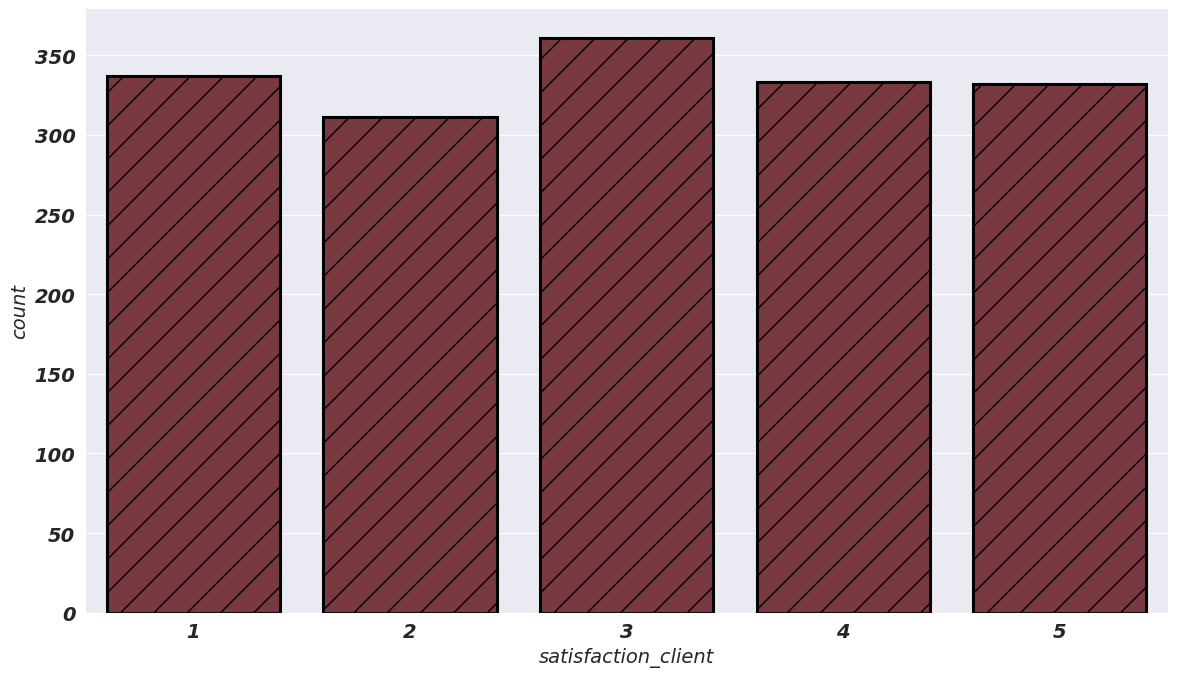

In [ ]:
# analyse de la target
sns.countplot(data=df,
              x='satisfaction_client',
              hatch='/',
              stat='count',
              width=.8,
              fill=True,
              color='#823038',
              ec='k',
              lw=2.2)
sns.despine(left=False, right=True, bottom=False, top=True)
plt.tight_layout()
plt.show()

In [ ]:
df['satisfaction_client'].value_counts(normalize=True, ascending=True, dropna=True, sort=True)

,proportion
satisfaction_client,
2,0.185783
5,0.198327
4,0.198925
1,0.201314
3,0.215651


In [ ]:
df.head(n=5
        )

,trajet_id,ville_depart,ville_arrivee,distance_km,duree_prevue_h,retard_min,prix_billet,nb_passagers,capacite_bus,type_bus,jour_semaine,periode_depart,condition_route,carburant_litre,satisfaction_client,surcharge,est_surcharged,prix_km,duree_prevue_min
1,2,Sokodé,Tsévié,NaN,2.9,124.0,9401.0,39.0,NaN,Standard,Dimanche,NaN,Moyenne,73.7,4,0.0,0,NaN,174.0
2,3,Dapaong,Sokodé,496.0,1.6,163.0,9228.0,56.0,NaN,Standard,Dimanche,Soir,Bonne,26.5,2,0.0,0,18.604839,96.0
3,4,Sokodé,Lomé,463.0,8.8,88.0,3618.0,NaN,NaN,VIP,Jeudi,Matin,Mauvaise,42.5,4,0.0,0,7.814255,528.0
4,5,Kara,Dapaong,130.0,3.4,32.0,7518.0,67.0,50.0,VIP,Dimanche,Après-midi,Mauvaise,21.5,1,17.0,1,57.830769,204.0
5,6,Atakpamé,Dapaong,643.0,7.7,172.0,3194.0,26.0,30.0,Standard,Samedi,Soir,Bonne,46.1,1,0.0,0,4.967341,462.0


In [ ]:
column_names

['trajet_id',
 'ville_depart',
 'ville_arrivee',
 'distance_km',
 'duree_prevue_h',
 'retard_min',
 'prix_billet',
 'nb_passagers',
 'capacite_bus',
 'type_bus',
 'jour_semaine',
 'periode_depart',
 'condition_route',
 'carburant_litre',
 'satisfaction_client']

In [ ]:
df.describe(include='number').round(decimals=2)

,trajet_id,distance_km,duree_prevue_h,retard_min,prix_billet,nb_passagers,capacite_bus,carburant_litre,satisfaction_client,surcharge,est_surcharged,prix_km
count,1674.00,1538.00,1543.00,1544.00,1545.00,1536.00,1539.00,1541.00,1674.00,1674.00,1674.0,1421.00
mean,984.09,355.68,6.77,92.24,6694.19,37.87,50.32,47.48,3.01,3.83,0.27,27.78
std,578.56,173.48,2.99,51.51,3080.11,19.08,13.93,18.43,1.41,8.03,0.45,28.04
min,2.00,50.00,1.50,0.00,1528.00,5.00,30.00,15.00,1.00,0.00,0.0,2.44
25%,479.25,207.25,4.20,49.00,3996.00,21.00,40.00,31.70,2.00,0.00,0.0,11.24
50%,980.50,360.00,6.80,94.00,6499.00,38.50,50.00,47.00,3.00,0.00,0.0,18.89
75%,1482.50,504.75,9.30,138.00,9525.00,54.00,60.00,63.50,4.00,3.00,1.0,32.67
max,2000.00,649.00,12.00,179.00,11997.00,79.00,70.00,80.00,5.00,39.00,1.0,230.42


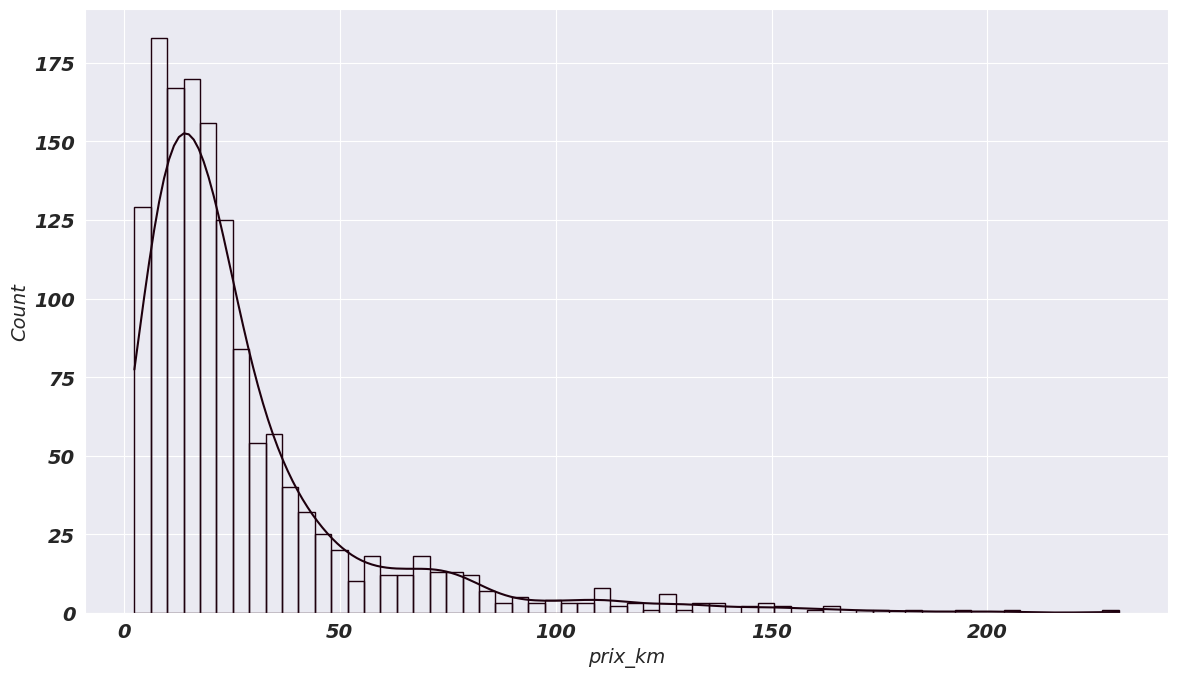

In [ ]:
sns.histplot(data=df,
             x='prix_km',
             fill=False,
             kde=True,
             element='bars',
             color='#1E000E',
             stat='count'
             )
plt.tight_layout()
plt.show()

In [ ]:
# imputation des donnees
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])


In [ ]:
# nominal columns
nominal_pipeline = Pipeline(steps=[
    ('ordinal', SimpleImputer(strategy='most_frequent')),
     ('onehot', OneHotEncoder(sparse_output=False,
                              handle_unknown='ignore',
                              drop='first'))
])

In [ ]:
list(ordinal_vars.values())

[['Standard', 'Climatisé', 'VIP'],
 ['Mauvaise', 'Moyenne', 'Bonne'],
 ['Matin', 'Après-midi', 'Soir']]

In [ ]:
ordinal_vars

{'type_bus': ['Standard', 'Climatisé', 'VIP'],
 'condition_route': ['Mauvaise', 'Moyenne', 'Bonne'],
 'periode_depart': ['Matin', 'Après-midi', 'Soir']}

In [ ]:
column_names

['trajet_id',
 'ville_depart',
 'ville_arrivee',
 'distance_km',
 'duree_prevue_h',
 'retard_min',
 'prix_billet',
 'nb_passagers',
 'capacite_bus',
 'type_bus',
 'jour_semaine',
 'periode_depart',
 'condition_route',
 'carburant_litre',
 'satisfaction_client']

In [ ]:
# ordinal columns
ordinal_pipeline = Pipeline(steps=[
    ('nominal', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(categories=list(ordinal_vars.values()),
                           handle_unknown='use_encoded_value',
                           unknown_value=-1))
])

In [ ]:
# on va maintenant creer notre pipeline de preprocessing
preprocessor = ColumnTransformer(transformers=[
    # ('num', numeric_pipeline, numeric_vars),
    ('ord', ordinal_pipeline, list(ordinal_vars.keys()))
], remainder='drop'
)

In [ ]:
random_forest_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=300,
                                          random_state=42))
])

In [ ]:
xg_boost_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('xg_boost', XGBClassifier(objective='multi:softprob',
                               num_class=5,
                               n_estimators=200,
                               learning_rate=0.05,
                               random_state=42,
                               max_depth=4,
                               subsample=.8))
])

In [ ]:
# separation de nos donnees
X = df.drop(columns=['trajet_id', 'satisfaction_client'], inplace=False)
y = df.filter(items=['satisfaction_client'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, test_size=.2, random_state=42, stratify=y)

In [ ]:
# on va encoder les donnees de y_train
y_train_encoded = y_train - 1

In [ ]:
ordinal_vars.keys()

dict_keys(['type_bus', 'periode_depart', 'condition_route'])

In [ ]:
# training of the model
random_forest_pipeline.fit(X_train, y_train_encoded)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('ord',
                                                  Pipeline(steps=[('nominal',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[['Standard',
                                                                                               'Climatisé',
                                                                                               'VIP'],
                                                                                              ['Matin',
                                                                                               'Après-midi',
                                                                                               'Soir'],
                                                                                              ['Mauvaise',
                                                                                               'Moyenne',
                                                                                               'Bonne']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['type_bus', 'periode_depart',
                                                   'condition_route'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [ ]:
# verification des performances du modele sur les donnees de tests
y_pred_test = random_forest_pipeline.predict(X_test) + 1

In [ ]:
accuracy_score(y_test, y_pred_test)

0.18507462686567164

In [ ]:
# Verification de l'overfitting
y_pred_train = random_forest_pipeline.predict(X_train) + 1

In [ ]:
type(y_pred_train)

numpy.ndarray

In [ ]:
y_pred_train

array([3, 1, 4, ..., 4, 2, 3])

In [ ]:
accuracy_score(y_train, y_pred_train)

0.2852875280059746

In [ ]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           1       0.18      0.18      0.18        68
           2       0.28      0.18      0.22        62
           3       0.17      0.25      0.20        72
           4       0.21      0.21      0.21        67
           5       0.11      0.09      0.10        66

    accuracy                           0.18       335
   macro avg       0.19      0.18      0.18       335
weighted avg       0.19      0.18      0.18       335



In [ ]:
mean_absolute_error(y_test, y_pred_test)

1.5850746268656717

In [ ]:
# Entrainement avec le nouveau modele
xg_boost_pipeline.fit(X_train, y_train_encoded)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('ord',
                                                  Pipeline(steps=[('nominal',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[['Standard',
                                                                                               'Climatisé',
                                                                                               'VIP'],
                                                                                              ['Matin',
                                                                                               'Après-midi',
                                                                                               'Soir'],
                                                                                              ['Mauvaise',
                                                                                               'Moyenne',
                                                                                               'Bonne']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['type_bus', 'periode_depart...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None, num_class=5, ...))])

In [ ]:
# prediction
y_pred_train_boost = xg_boost_pipeline.predict(X_train) + 1

In [ ]:
# accuracy score
accuracy_score(y_train, y_pred_train_boost)

0.2852875280059746

In [ ]:
# sur les donnees de test
y_pred_test_boost = xg_boost_pipeline.predict(X_test) + 1

In [ ]:
accuracy_score(y_test, y_pred_test_boost)

0.18507462686567164